# Прогнозирование типа аудиторского заключения по финансовым показателям
## Финальный проект — Data Science: машинное обучение и нейронные сети

**Бизнес-задача:** Можно ли по финансовой отчётности компании заранее определить,
получит ли она **модифицированное** аудиторское заключение?

**Тип задачи DS:** Бинарная классификация
- **0** — Немодифицированное заключение (без оговорок)
- **1** — Модифицированное заключение (с оговоркой, отрицательное, отказ)

**Метрики качества:** ROC-AUC, F1-score, Accuracy

**Данные:** годовые отчёты публичных компаний Турции, 2010–2024 гг.

> *Методологическое замечание.* Датасет содержит синтетические подтипы,
> созданные авторами на основе моделей банкротства. В данном исследовании
> используются только реальные аудиторские заключения, что исключает
> круговую зависимость между признаками и целевой переменной.

## 0. Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.metrics          import (accuracy_score, f1_score, roc_auc_score,
                                      classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection       import permutation_importance

RANDOM_STATE = 42
print('Библиотеки загружены успешно')

Библиотеки загружены успешно


## 1. Загрузка данных

In [2]:
from google.colab import files
import io

print('Загрузите файл refined_data.csv')
uploaded = files.upload()
df_raw = pd.read_csv(io.BytesIO(uploaded['refined_data.csv']))
print(f'Загружено: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов')

Загрузите файл refined_data.csv


Saving refined_data.csv to refined_data.csv
Загружено: 27298 строк, 53 столбцов


## 2. Изучение структуры данных (EDA — часть 1)

In [3]:
# Типы данных
print('=== ТИПЫ ДАННЫХ ===')
print(df_raw.dtypes.value_counts())
print()

# Пропущенные значения
print('=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ (топ-10) ===')
miss = df_raw.isnull().sum().sort_values(ascending=False)
print(miss[miss > 0].head(10).to_string())
print()

# Дубликаты
dups = df_raw.duplicated().sum()
print(f'=== ДУБЛИКАТЫ: {dups} строк ===')
print()

# Размер
print(f'Всего строк: {len(df_raw)}')
print(f'Уникальных компаний: {df_raw["Şirketin Kodu"].nunique()}')
print(f'Типы периодов: {df_raw["Periyot"].value_counts().to_dict()}')

=== ТИПЫ ДАННЫХ ===
float64    48
object      4
int64       1
Name: count, dtype: int64

=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ (топ-10) ===
Görüs Tipi    16547

=== ДУБЛИКАТЫ: 4 строк ===

Всего строк: 27298
Уникальных компаний: 555
Типы периодов: {'6 Aylık': 6885, 'Yıllık': 6860, '3 Aylık': 6778, '9 Aylık': 6775}


## 3. Подготовка данных и целевая переменная

In [4]:
# Фильтрация: только годовые отчёты с заключением и ненулевыми активами
df = df_raw[
    (df_raw['Periyot'] == 'Yıllık') &
    (df_raw['Görüs Tipi'].notna()) &
    (df_raw['Toplam Varlıklar'] > 0)
].copy().reset_index(drop=True)

print(f'Рабочий датасет: {len(df)} наблюдений')
print(f'Период: {df["Yıl"].min()}–{df["Yıl"].max()}')
print(f'Уникальных компаний: {df["Şirketin Kodu"].nunique()}')
print()
print('Типы заключений:')
print(df['Görüs Tipi'].value_counts().to_string())

Рабочий датасет: 5097 наблюдений
Период: 2008–2024
Уникальных компаний: 526

Типы заключений:
Görüs Tipi
Olumlu++                      1122
Olumlu++++                    1080
Şartlı                         501
Olumlu+                        457
Olumlu+++                      456
Olumlu                         453
Olumlu-                        442
Olumlu--                       297
Olumlu---                      193
Olumlu----                      48
Görüş bildirmekten kaçınma      46
Olumsuz                          2


In [5]:
# ЦЕЛЕВАЯ ПЕРЕМЕННАЯ: бинарная классификация
# 0 = немодифицированное (начинается с 'Olumlu')
# 1 = модифицированное   (всё остальное)
df['target'] = df['Görüs Tipi'].apply(
    lambda x: 0 if str(x).strip().startswith('Olumlu') else 1
).astype(int)

n0 = (df['target'] == 0).sum()
n1 = (df['target'] == 1).sum()
print('Распределение целевой переменной:')
print(f'  0 — Немодифицированное: {n0:>5} ({n0/len(df)*100:.1f}%)')
print(f'  1 — Модифицированное:   {n1:>5} ({n1/len(df)*100:.1f}%)')
print()
print('Дисбаланс будет компенсирован параметром class_weight="balanced"')

Распределение целевой переменной:
  0 — Немодифицированное:  4548 (89.2%)
  1 — Модифицированное:     549 (10.8%)

Дисбаланс будет компенсирован параметром class_weight="balanced"


In [6]:
# 12 финансовых коэффициентов — рассчитываются из стандартной отчётности
FEATURES = [
    'Cari Oran',               # Текущая ликвидность
    'Asit Test Oranı',         # Быстрая ликвидность
    'Nakit Oranı',             # Денежная ликвидность
    'Özsermaye / Aktif',       # Коэффициент автономии
    'Borç Kaynak Oranı',       # Долговая нагрузка
    'Aktif Karlılık (%)',      # Рентабельность активов (ROA)
    'Net Kar Marjı',           # Чистая рентабельность продаж
    'Özsermaye Karlılığı (%)', # Рентабельность собственного капитала (ROE)
    'Aktif Devir Hızı',        # Оборачиваемость активов
    'Toplam Borç / Özsermaye', # Соотношение долга к капиталу
    'Finansal Kaldıraç',       # Финансовый рычаг
    'Altman Z-Skoru',          # Z-счёт Альтмана
]

# Русские названия для графиков
RU = {
    'Cari Oran':               'Текущая ликвидность',
    'Asit Test Oranı':         'Быстрая ликвидность',
    'Nakit Oranı':             'Денежная ликвидность',
    'Özsermaye / Aktif':       'Коэф. автономии',
    'Borç Kaynak Oranı':       'Долговая нагрузка',
    'Aktif Karlılık (%)':      'ROA (%)',
    'Net Kar Marjı':           'Чистая рентабельность',
    'Özsermaye Karlılığı (%)': 'ROE (%)',
    'Aktif Devir Hızı':        'Оборачиваемость активов',
    'Toplam Borç / Özsermaye': 'Долг / Капитал',
    'Finansal Kaldıraç':       'Финансовый рычаг',
    'Altman Z-Skoru':          'Z-счёт Альтмана',
}

available = [f for f in FEATURES if f in df.columns]
df = df.dropna(subset=available + ['target'])
print(f'Признаков: {len(available)}')
print(f'Наблюдений после удаления пропусков: {len(df)}')

Признаков: 12
Наблюдений после удаления пропусков: 5097


## 4. Исследовательский анализ данных (EDA — часть 2)

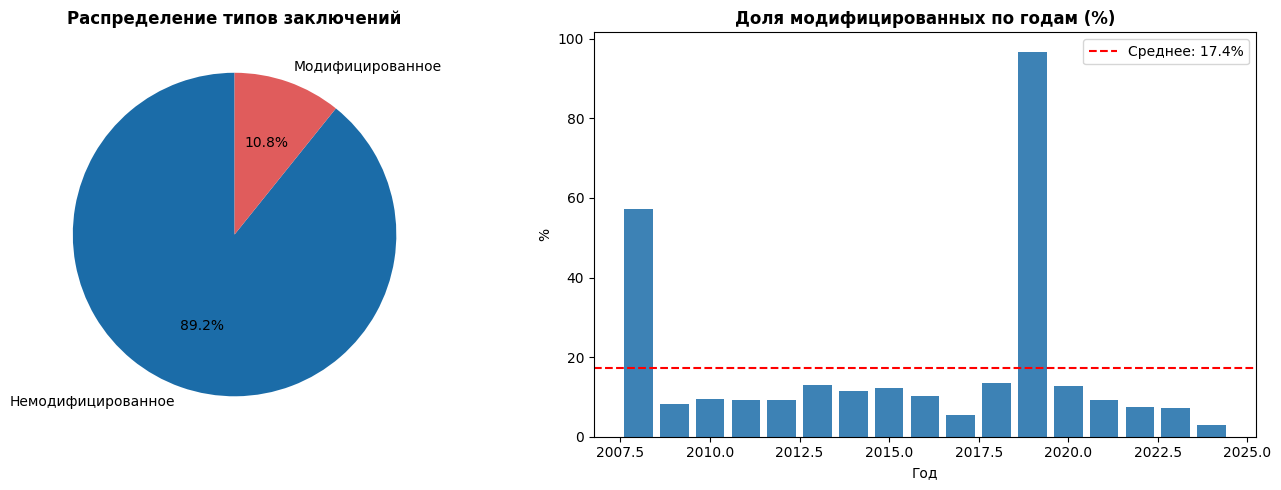

In [7]:
# 4.1 Распределение и динамика
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n0 = (df['target'] == 0).sum()
n1 = (df['target'] == 1).sum()
ax1.pie([n0, n1],
        labels=['Немодифицированное', 'Модифицированное'],
        colors=['#1B6CA8', '#E05C5C'],
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Распределение типов заключений', fontweight='bold')

yearly = df.groupby('Yıl')['target'].mean() * 100
ax2.bar(yearly.index, yearly.values, color='#1B6CA8', alpha=0.85)
ax2.axhline(yearly.mean(), color='red', linestyle='--',
            label=f'Среднее: {yearly.mean():.1f}%')
ax2.set_title('Доля модифицированных по годам (%)', fontweight='bold')
ax2.set_xlabel('Год'); ax2.set_ylabel('%')
ax2.legend()
plt.tight_layout(); plt.show()

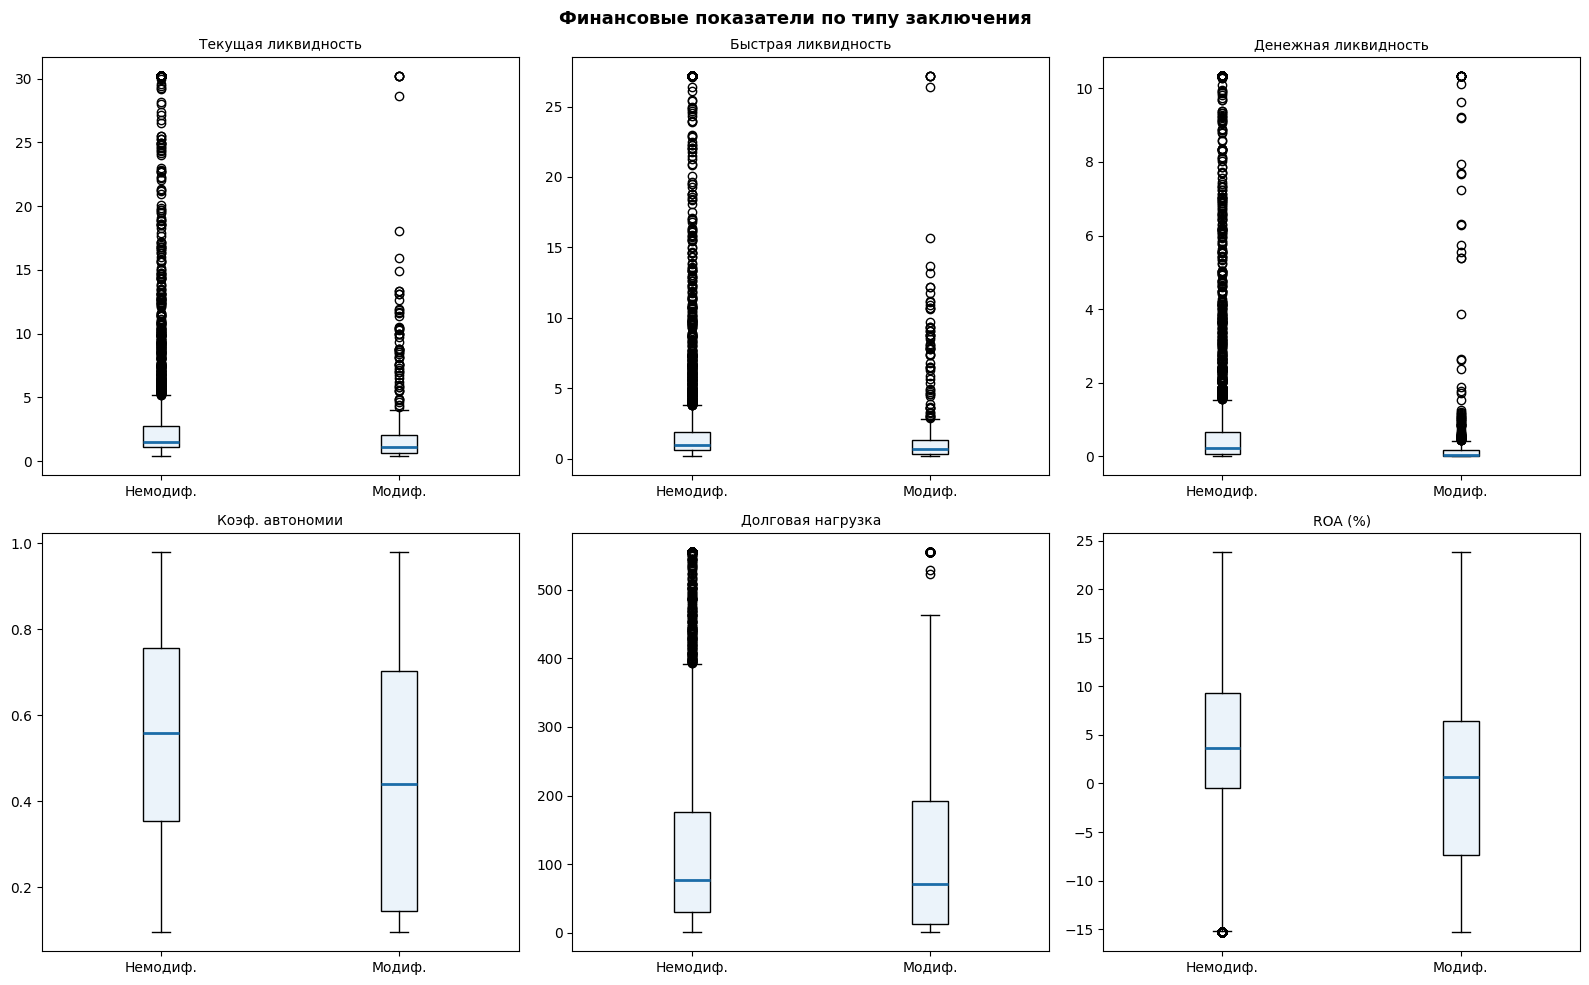

Различия медиан подтверждают информативность признаков.


In [8]:
# 4.2 Boxplot — различия медиан по типам заключений
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_feats = available[:6]

for ax, feat in zip(axes.flatten(), plot_feats):
    lo, hi = df[feat].quantile(0.05), df[feat].quantile(0.95)
    d0 = df[df['target'] == 0][feat].clip(lo, hi)
    d1 = df[df['target'] == 1][feat].clip(lo, hi)
    ax.boxplot([d0, d1], labels=['Немодиф.', 'Модиф.'],
               patch_artist=True,
               boxprops=dict(facecolor='#EBF3FA'),
               medianprops=dict(color='#1B6CA8', linewidth=2))
    ax.set_title(RU.get(feat, feat), fontsize=10)

plt.suptitle('Финансовые показатели по типу заключения', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('Различия медиан подтверждают информативность признаков.')

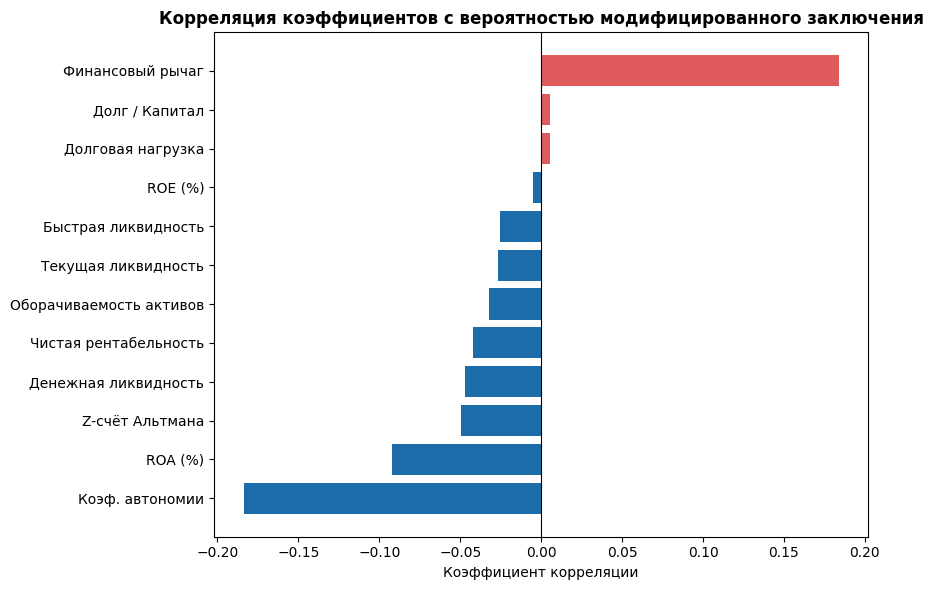

Корреляция с целевой переменной:
  Коэф. автономии                          -0.184
  ROA (%)                                  -0.092
  Z-счёт Альтмана                          -0.050
  Денежная ликвидность                     -0.047
  Чистая рентабельность                    -0.042
  Оборачиваемость активов                  -0.032
  Текущая ликвидность                      -0.027
  Быстрая ликвидность                      -0.025
  ROE (%)                                  -0.005
  Долговая нагрузка                        +0.006
  Долг / Капитал                           +0.006
  Финансовый рычаг                         +0.184


In [9]:
# 4.3 Корреляция признаков с целевой переменной
corr = df[available + ['target']].corr()['target'].drop('target').sort_values()
corr.index = [RU.get(i, i) for i in corr.index]

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#E05C5C' if v > 0 else '#1B6CA8' for v in corr]
ax.barh(corr.index, corr.values, color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Корреляция коэффициентов с вероятностью модифицированного заключения',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Коэффициент корреляции')
plt.tight_layout(); plt.show()

print('Корреляция с целевой переменной:')
for feat, val in corr.items():
    print(f'  {feat:<40} {val:+.3f}')

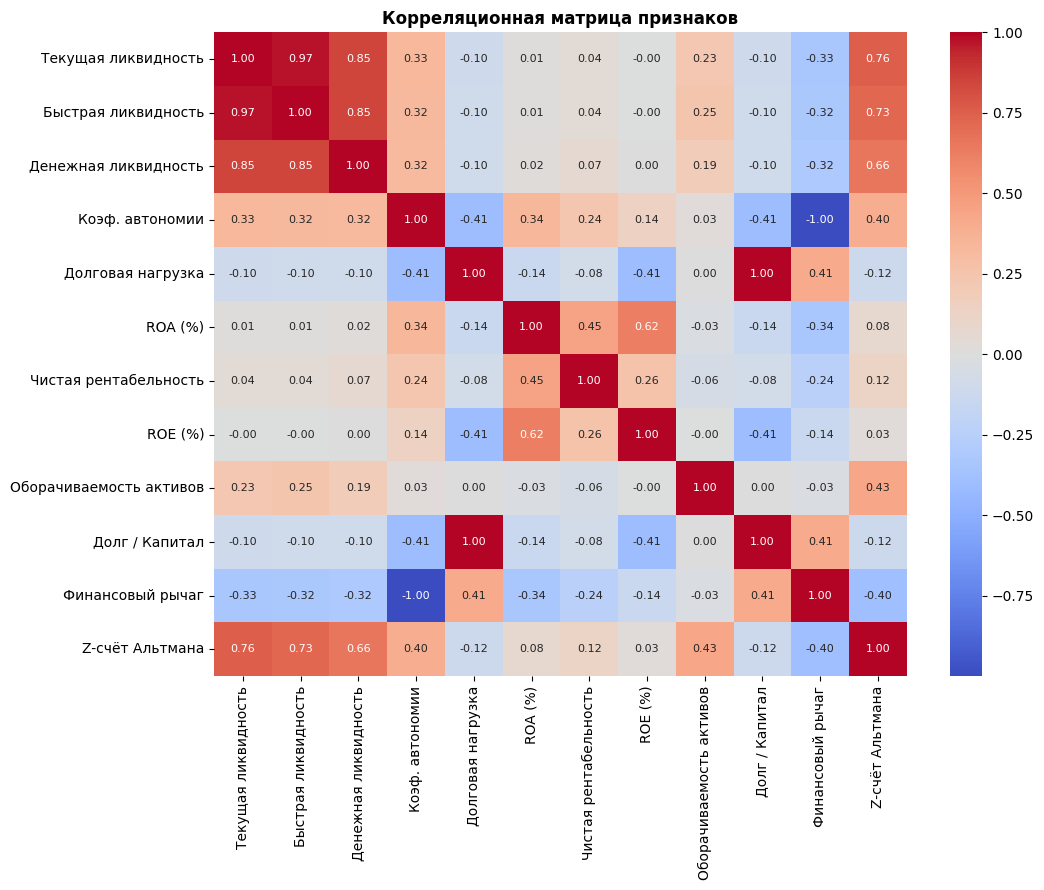

In [10]:
# 4.4 Корреляционная матрица признаков
df_clip = df[available].copy()
for col in available:
    q01, q99 = df_clip[col].quantile([0.01, 0.99])
    df_clip[col] = df_clip[col].clip(q01, q99)
df_clip.columns = [RU.get(c, c) for c in df_clip.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_clip.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Корреляционная матрица признаков', fontweight='bold')
plt.tight_layout(); plt.show()

In [11]:
# 4.5 Описательная статистика
stats = df[available].describe().round(3)
stats.columns = [RU.get(c, c) for c in stats.columns]
print('Описательная статистика финансовых коэффициентов:')
print(stats.to_string())

Описательная статистика финансовых коэффициентов:
       Текущая ликвидность  Быстрая ликвидность  Денежная ликвидность  Коэф. автономии  Долговая нагрузка   ROA (%)  Чистая рентабельность    ROE (%)  Оборачиваемость активов  Долг / Капитал  Финансовый рычаг  Z-счёт Альтмана
count             5097.000             5097.000              5097.000         5097.000           5097.000  5097.000               5097.000   5097.000                 5097.000        5097.000          5097.000         5097.000
mean                17.181               15.088                 4.230            0.524             41.077     3.802               -267.764     21.737                    1.801           0.411            47.571           10.450
std                187.140              177.581                25.986            0.362          10057.271    19.880              27189.975   1297.646                    9.523         100.573            36.197           53.980
min                  0.000                0.00

## 5. Предобработка данных

In [12]:
# 5.1 Winsorization — ограничение выбросов на уровне 1–99 перцентилей
df_model = df[available].copy()
winsor_bounds = {}
for col in available:
    lo, hi = df_model[col].quantile([0.01, 0.99])
    df_model[col] = df_model[col].clip(lo, hi)
    winsor_bounds[col] = (lo, hi)
print('Winsorization применена')

# 5.2 Train/Test split 80/20 со стратификацией по целевой переменной
y = df['target'].values
X = df_model.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Доля модифицированных в train: {y_train.mean()*100:.1f}%')
print(f'Доля модифицированных в test:  {y_test.mean()*100:.1f}%')

# 5.3 Стандартизация — параметры только на train, применяем к test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Стандартизация применена (fit на train, transform на test)')

Winsorization применена
Train: 4077 | Test: 1020
Доля модифицированных в train: 10.8%
Доля модифицированных в test:  10.8%
Стандартизация применена (fit на train, transform на test)


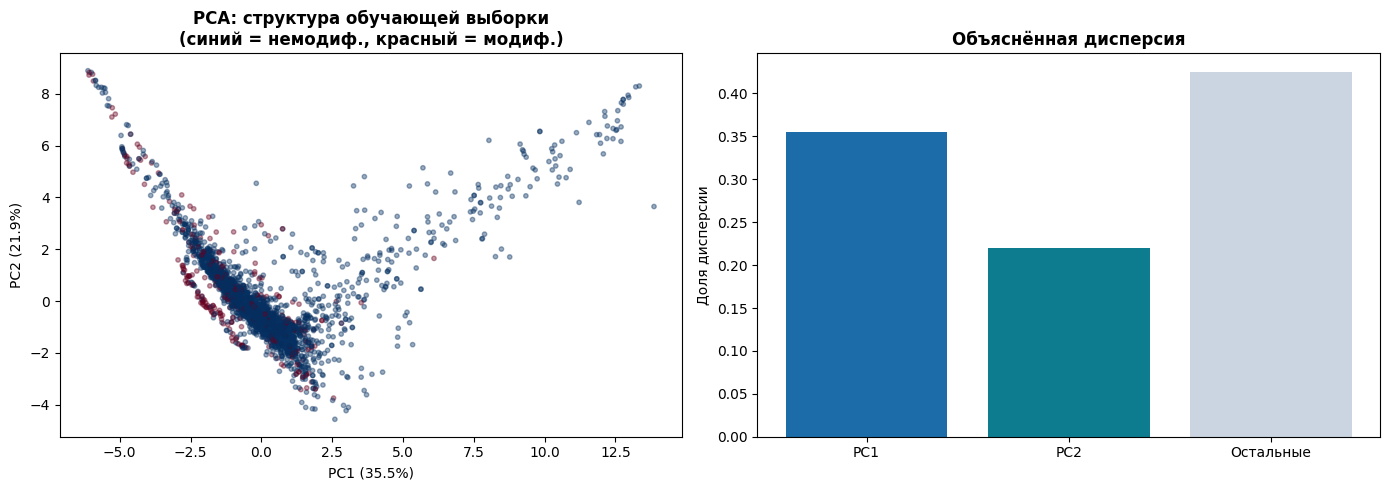

In [13]:
# 5.4 PCA — визуализация структуры данных (только для отображения, не для моделей)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=y_train, cmap='RdBu_r', alpha=0.4, s=10)
axes[0].set_title('PCA: структура обучающей выборки\n'
                  '(синий = немодиф., красный = модиф.)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].bar(['PC1', 'PC2', 'Остальные'],
            [pca.explained_variance_ratio_[0],
             pca.explained_variance_ratio_[1],
             1 - pca.explained_variance_ratio_[:2].sum()],
            color=['#1B6CA8', '#0D7C8F', '#CBD5E1'])
axes[1].set_title('Объяснённая дисперсия', fontweight='bold')
axes[1].set_ylabel('Доля дисперсии')
plt.tight_layout(); plt.show()

## 6. Обучение моделей

Обучаем 6 классификационных моделей — от логистической регрессии до нейронной сети.
`class_weight='balanced'` компенсирует дисбаланс классов 89%/11%.

In [14]:
models = {
    'Логистическая регрессия':  LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'L2-логистическая (Ridge)': LogisticRegression(
        C=0.5, penalty='l2', max_iter=1000,
        class_weight='balanced', random_state=RANDOM_STATE),
    'Дерево решений':           DecisionTreeClassifier(
        max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
    'Случайный лес':            RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Градиентный бустинг':      GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE),
    'Нейронная сеть (MLP)':     MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500, random_state=RANDOM_STATE),
}

# Кросс-валидация 5-fold, метрика ROC-AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Кросс-валидация (5-fold, ROC-AUC):')
print('-' * 60)
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<35} | {scores.mean():.3f} ± {scores.std():.3f}')
print('-' * 60)

Кросс-валидация (5-fold, ROC-AUC):
------------------------------------------------------------
Логистическая регрессия             | 0.656 ± 0.033
L2-логистическая (Ridge)            | 0.656 ± 0.033
Дерево решений                      | 0.722 ± 0.019
Случайный лес                       | 0.764 ± 0.018
Градиентный бустинг                 | 0.775 ± 0.017
Нейронная сеть (MLP)                | 0.715 ± 0.025
------------------------------------------------------------


In [15]:
# Обучение на полной обучающей выборке
trained = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    trained[name] = model
    print(f'{name} — обучена')

Логистическая регрессия — обучена
L2-логистическая (Ridge) — обучена
Дерево решений — обучена
Случайный лес — обучена
Градиентный бустинг — обучена
Нейронная сеть (MLP) — обучена


## 7. Оценка моделей на тестовой выборке

In [16]:
results = {}
print('Результаты на тестовой выборке:')
print('-' * 70)
for name, model in trained.items():
    yp    = model.predict(X_test_sc)
    yprob = model.predict_proba(X_test_sc)[:, 1]
    acc   = accuracy_score(y_test, yp)
    f1m   = f1_score(y_test, yp, pos_label=1)
    auc   = roc_auc_score(y_test, yprob)
    results[name] = {'Accuracy': acc, 'F1-mod': f1m, 'ROC-AUC': auc,
                     'yp': yp, 'yprob': yprob}
    print(f'{name:<35} | Acc:{acc:.3f} | F1-mod:{f1m:.3f} | AUC:{auc:.3f}')
print('-' * 70)

best = max(results, key=lambda n: results[n]['ROC-AUC'])
print(f'\nЛучшая модель: {best}')
print(f'ROC-AUC = {results[best]["ROC-AUC"]:.3f}')
print(f'F1-mod  = {results[best]["F1-mod"]:.3f}')

Результаты на тестовой выборке:
----------------------------------------------------------------------
Логистическая регрессия             | Acc:0.600 | F1-mod:0.218 | AUC:0.612
L2-логистическая (Ridge)            | Acc:0.600 | F1-mod:0.218 | AUC:0.612
Дерево решений                      | Acc:0.730 | F1-mod:0.282 | AUC:0.697
Случайный лес                       | Acc:0.900 | F1-mod:0.329 | AUC:0.775
Градиентный бустинг                 | Acc:0.896 | F1-mod:0.243 | AUC:0.773
Нейронная сеть (MLP)                | Acc:0.891 | F1-mod:0.213 | AUC:0.751
----------------------------------------------------------------------

Лучшая модель: Случайный лес
ROC-AUC = 0.775
F1-mod  = 0.329


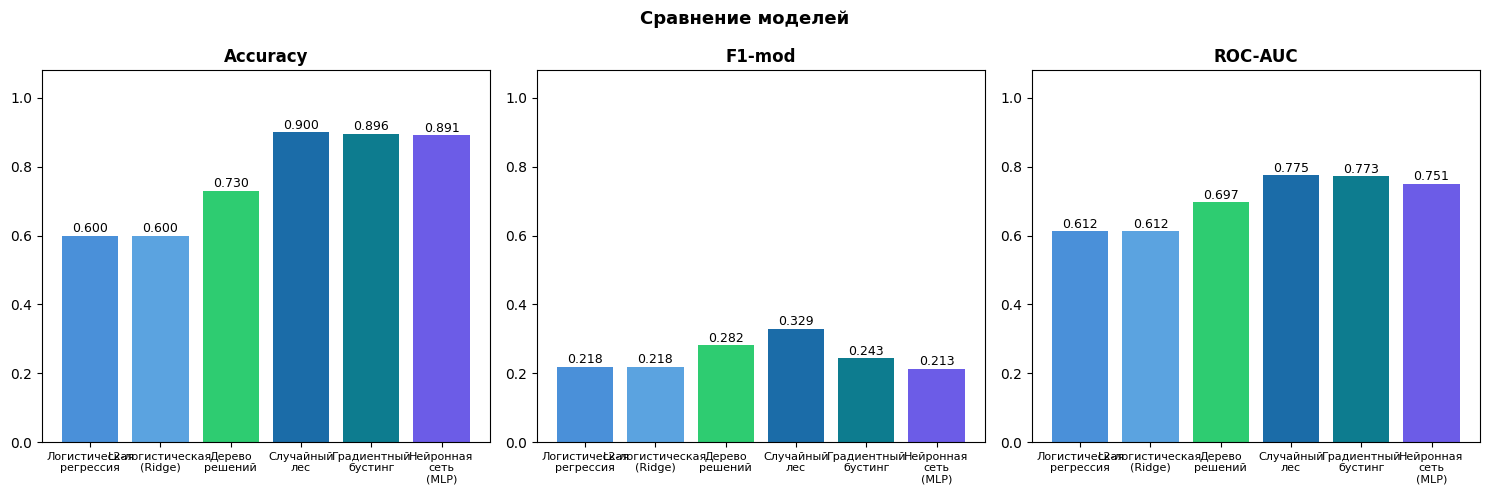

In [17]:
# Сравнительный график
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = ['#4A90D9','#5BA3E0','#2ECC71','#1B6CA8','#0D7C8F','#6C5CE7']

for ax, metric in zip(axes, ['Accuracy', 'F1-mod', 'ROC-AUC']):
    vals  = [results[n][metric] for n in results]
    names = list(results.keys())
    bars  = ax.bar(range(len(names)), vals, color=palette)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.08)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Сравнение моделей', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

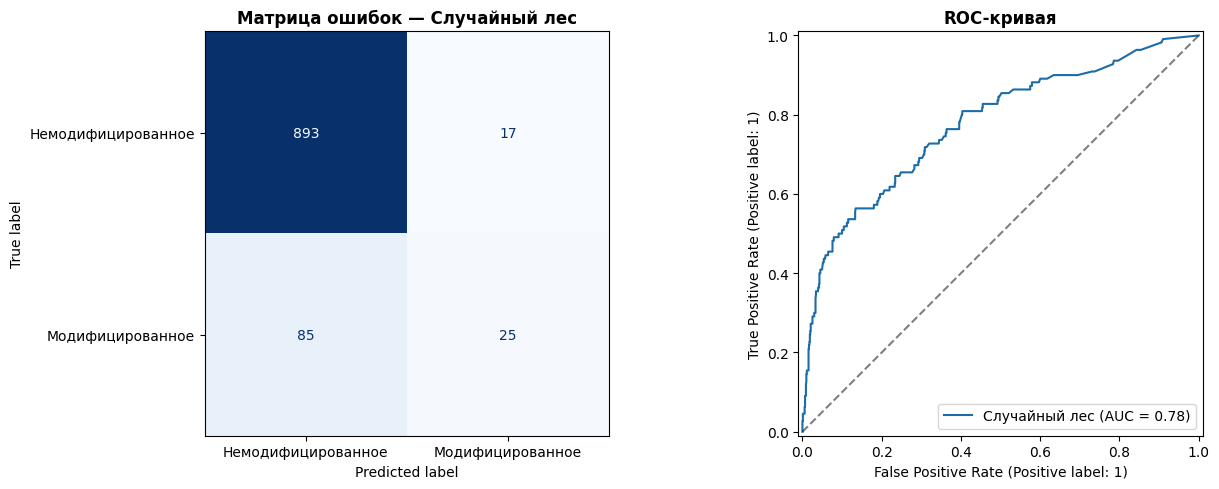

                    precision    recall  f1-score   support

Немодифицированное       0.91      0.98      0.95       910
  Модифицированное       0.60      0.23      0.33       110

          accuracy                           0.90      1020
         macro avg       0.75      0.60      0.64      1020
      weighted avg       0.88      0.90      0.88      1020

Верно определено модифицированных: 25/110 (22.7%)
Пропущено модифицированных (ложноотрицательные): 85 — критичный тип ошибки


In [18]:
# Матрица ошибок и ROC-кривая лучшей модели
best_model = trained[best]
yp_best    = results[best]['yp']
yprob_best = results[best]['yprob']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, yp_best)
ConfusionMatrixDisplay(cm, display_labels=['Немодифицированное','Модифицированное']
    ).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Матрица ошибок — {best}', fontweight='bold')

RocCurveDisplay.from_predictions(y_test, yprob_best,
    ax=axes[1], name=best, color='#1B6CA8')
axes[1].plot([0,1],[0,1],'k--', alpha=0.5)
axes[1].set_title('ROC-кривая', fontweight='bold')
plt.tight_layout(); plt.show()

print(classification_report(y_test, yp_best,
      target_names=['Немодифицированное','Модифицированное']))

tn, fp, fn, tp_ = cm.ravel()
print(f'Верно определено модифицированных: {tp_}/{tp_+fn} ({tp_/(tp_+fn)*100:.1f}%)')
print(f'Пропущено модифицированных (ложноотрицательные): {fn} — критичный тип ошибки')

## 8. Важность признаков

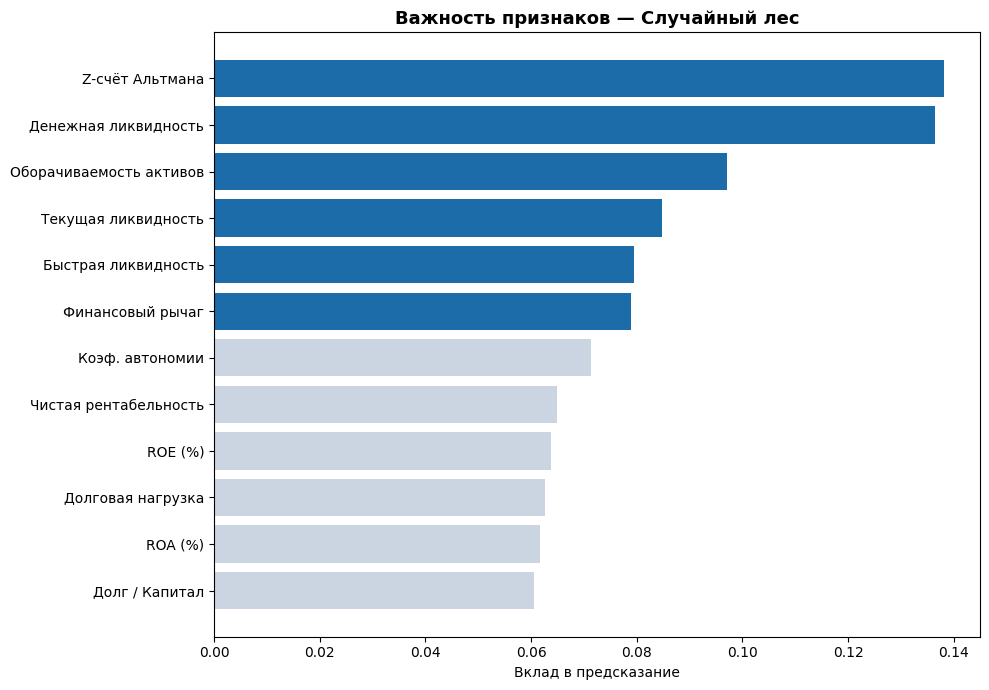

Топ-5 признаков:
  Z-счёт Альтмана                               0.1381
  Денежная ликвидность                          0.1364
  Оборачиваемость активов                       0.0970
  Текущая ликвидность                           0.0848
  Быстрая ликвидность                           0.0795


In [19]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=available)
elif hasattr(best_model, 'coef_'):
    imp = pd.Series(np.abs(best_model.coef_[0]), index=available)
else:
    pi  = permutation_importance(best_model, X_test_sc, y_test,
                                  scoring='roc_auc', n_repeats=15,
                                  random_state=RANDOM_STATE)
    imp = pd.Series(pi.importances_mean, index=available)

imp = imp.sort_values(ascending=True)
imp.index = [RU.get(i, i) for i in imp.index]

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#1B6CA8' if v >= imp.median() else '#CBD5E1' for v in imp]
ax.barh(imp.index, imp.values, color=colors_imp)
ax.set_title(f'Важность признаков — {best}', fontsize=13, fontweight='bold')
ax.set_xlabel('Вклад в предсказание')
plt.tight_layout(); plt.show()

print('Топ-5 признаков:')
for feat, val in imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<45} {val:.4f}')

## 9. Анализ ошибок

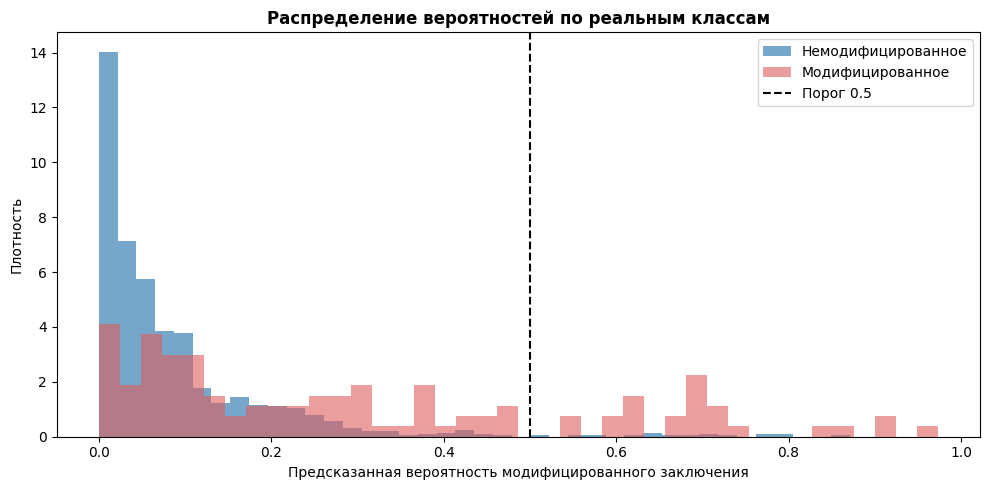

Хорошая модель даёт два чётких пика — около 0 и около 1.


In [20]:
# Распределение предсказанных вероятностей по реальным классам
fig, ax = plt.subplots(figsize=(10, 5))
for cls, color, label in [(0,'#1B6CA8','Немодифицированное'),
                           (1,'#E05C5C','Модифицированное')]:
    mask = y_test == cls
    ax.hist(yprob_best[mask], bins=40, alpha=0.6,
            color=color, label=label, density=True)
ax.axvline(0.5, color='black', linestyle='--', label='Порог 0.5')
ax.set_xlabel('Предсказанная вероятность модифицированного заключения')
ax.set_ylabel('Плотность')
ax.set_title('Распределение вероятностей по реальным классам', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print('Хорошая модель даёт два чётких пика — около 0 и около 1.')

## 10. Нейронная сеть — сравнение архитектур

In [21]:
mlp_configs = {
    'MLP (1 слой, 64)':         (64,),
    'MLP (2 слоя, 128-64)':     (128, 64),
    'MLP (3 слоя, 128-64-32)':  (128, 64, 32),
    'MLP (3 слоя, 256-128-64)': (256, 128, 64),
}

print('Сравнение архитектур нейронной сети:')
print('-' * 55)
mlp_results = {}
for name, layers in mlp_configs.items():
    m = MLPClassifier(hidden_layer_sizes=layers, max_iter=500,
                      early_stopping=True, random_state=RANDOM_STATE)
    m.fit(X_train_sc, y_train)
    auc = roc_auc_score(y_test, m.predict_proba(X_test_sc)[:, 1])
    f1m = f1_score(y_test, m.predict(X_test_sc), pos_label=1)
    mlp_results[name] = {'model': m, 'ROC-AUC': auc, 'F1-mod': f1m}
    print(f'{name:<35} | AUC:{auc:.3f} | F1-mod:{f1m:.3f}')
print('-' * 55)
best_mlp = max(mlp_results, key=lambda n: mlp_results[n]['ROC-AUC'])
print(f'\nЛучшая архитектура: {best_mlp}')

Сравнение архитектур нейронной сети:
-------------------------------------------------------
MLP (1 слой, 64)                    | AUC:0.599 | F1-mod:0.068
MLP (2 слоя, 128-64)                | AUC:0.671 | F1-mod:0.159
MLP (3 слоя, 128-64-32)             | AUC:0.664 | F1-mod:0.129
MLP (3 слоя, 256-128-64)            | AUC:0.686 | F1-mod:0.156
-------------------------------------------------------

Лучшая архитектура: MLP (3 слоя, 256-128-64)


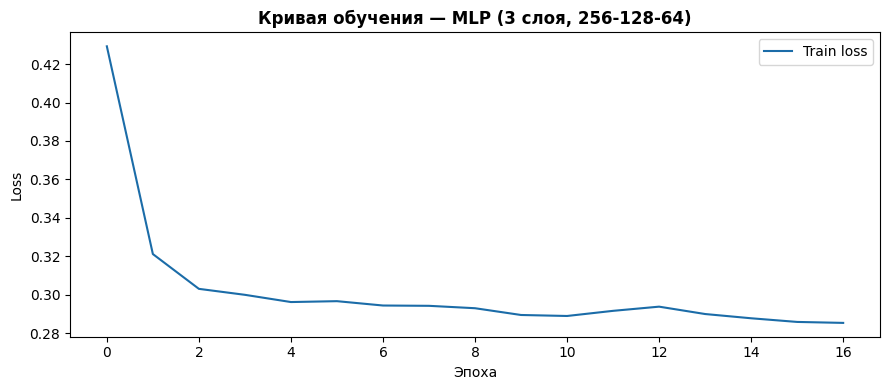

In [22]:
# Кривая обучения лучшей MLP
mlp_best = mlp_results[best_mlp]['model']
if hasattr(mlp_best, 'loss_curve_'):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(mlp_best.loss_curve_, color='#1B6CA8', label='Train loss')
    ax.set_title(f'Кривая обучения — {best_mlp}', fontweight='bold')
    ax.set_xlabel('Эпоха'); ax.set_ylabel('Loss')
    ax.legend(); plt.tight_layout(); plt.show()

## 11. Мысленный эксперимент: белорусские ОАО

Модель, обученная на турецких данных, применяется к белорусским организациям.
Она предсказывает **вероятность (0–100%)** получения модифицированного заключения.

*Ограничение:* модель обучена на данных МСФО. Для РБ (НСБУ) нужна калибровка.

In [23]:
print('Загрузите файл audit_dataset.csv')
uploaded2 = files.upload()
df_by_raw = pd.read_csv(io.BytesIO(uploaded2[list(uploaded2.keys())[0]]),
                        encoding='utf-8-sig')
print(f'Загружено: {len(df_by_raw)} организаций')

Загрузите файл audit_dataset.csv


Saving audit_dataset.csv to audit_dataset.csv
Загружено: 28 организаций


In [24]:
# Расчёт коэффициентов по тем же формулам
df_by = df_by_raw.copy()
num_cols = df_by.columns.drop(['Entity_Name', 'Year'])
df_by[num_cols] = df_by[num_cols].apply(pd.to_numeric, errors='coerce')

eps = 1e-6
df_by['Total_Assets'] = df_by['LT_Assets'] + df_by['ST_Assets']
df_by['Total_Liab']   = df_by['LT_Liab']   + df_by['ST_Liab']
df_by['EBIT']         = df_by['Op_Profit']  + df_by['Interest']

df_by_feat = pd.DataFrame({
    'Cari Oran':               df_by['ST_Assets'] / (df_by['ST_Liab'] + eps),
    'Asit Test Oranı':         (df_by['ST_Assets'] - df_by['Inventory']) / (df_by['ST_Liab'] + eps),
    'Nakit Oranı':             df_by['Cash'] / (df_by['ST_Liab'] + eps),
    'Özsermaye / Aktif':       df_by['Equity'] / (df_by['Total_Assets'] + eps),
    'Borç Kaynak Oranı':       df_by['Total_Liab'] / (df_by['Total_Assets'] + eps),
    'Aktif Karlılık (%)':      df_by['Net_Profit'] / (df_by['Total_Assets'] + eps) * 100,
    'Net Kar Marjı':           df_by['Net_Profit'] / (df_by['Revenue'] + eps),
    'Özsermaye Karlılığı (%)': df_by['Net_Profit'] / (df_by['Equity'].abs() + eps) * 100,
    'Aktif Devir Hızı':        df_by['Revenue'] / (df_by['Total_Assets'] + eps),
    'Toplam Borç / Özsermaye': df_by['Total_Liab'] / (df_by['Equity'].abs() + eps),
    'Finansal Kaldıraç':       df_by['Total_Assets'] / (df_by['Equity'].abs() + eps),
    'Altman Z-Skoru':         (1.2*(df_by['ST_Assets']-df_by['ST_Liab'])/(df_by['Total_Assets']+eps) +
                               1.4*df_by['Retained_Earnings']/(df_by['Total_Assets']+eps) +
                               3.3*df_by['EBIT']/(df_by['Total_Assets']+eps) +
                               0.6*df_by['Equity']/(df_by['Total_Liab']+eps) +
                               1.0*df_by['Revenue']/(df_by['Total_Assets']+eps)),
})

# Winsorization и заполнение медианой по параметрам турецкого датасета
df_model_orig = pd.DataFrame(X_train, columns=available)  # для медиан
for col in available:
    lo, hi = winsor_bounds[col]
    df_by_feat[col] = df_by_feat[col].clip(lo, hi)
    med = df_model_orig[col].median() if col in df_model_orig else 0
    df_by_feat[col] = df_by_feat[col].fillna(med)

X_by = scaler.transform(df_by_feat[available].values)
print(f'Коэффициенты рассчитаны для {len(X_by)} организаций')

Коэффициенты рассчитаны для 28 организаций


In [25]:
# Предсказание
prob = best_model.predict_proba(X_by)[:, 1]
pred = best_model.predict(X_by)

label_map = {0:'Немодифицированное', 2:'Модифицированное (с оговоркой)',
             3:'Нет аудита', 4:'Нет аудита'}

result = pd.DataFrame({
    'Организация':          df_by['Entity_Name'].str.replace(r'[ОАЗ]АО «|»','',regex=True).str.strip(),
    'Заключение РБ':        df_by['Label'].map(label_map).fillna('Неизвестно'),
    'P(модифиц.), %':       (prob * 100).round(1),
    'Предсказание модели':  pd.Series(pred).map({0:'Немодифицированное',
                                                  1:'Модифицированное'}),
})
result['Совпадение'] = result.apply(
    lambda r: '✓' if
    (r['Заключение РБ']=='Немодифицированное' and r['Предсказание модели']=='Немодифицированное')
    or (r['Заключение РБ']!='Немодифицированное' and r['Предсказание модели']=='Модифицированное')
    else '⚠', axis=1)

print(result.to_string(index=False))

                                Организация                  Заключение РБ  P(модифиц.), % Предсказание модели Совпадение
              Скидельский сахарный комбинат             Немодифицированное            17.5  Немодифицированное          ✓
                                     БелВТИ             Немодифицированное            21.4  Немодифицированное          ✓
               Институт Гомельгражданпроект             Немодифицированное            14.9  Немодифицированное          ✓
                                    Евроопт             Немодифицированное            21.4  Немодифицированное          ✓
                   Светлогорский агросервис Модифицированное (с оговоркой)            20.4  Немодифицированное          ⚠
                            Молодая гвардия Модифицированное (с оговоркой)            22.1  Немодифицированное          ⚠
                       Барановичипромбурвод             Немодифицированное             9.5  Немодифицированное          ✓
                        

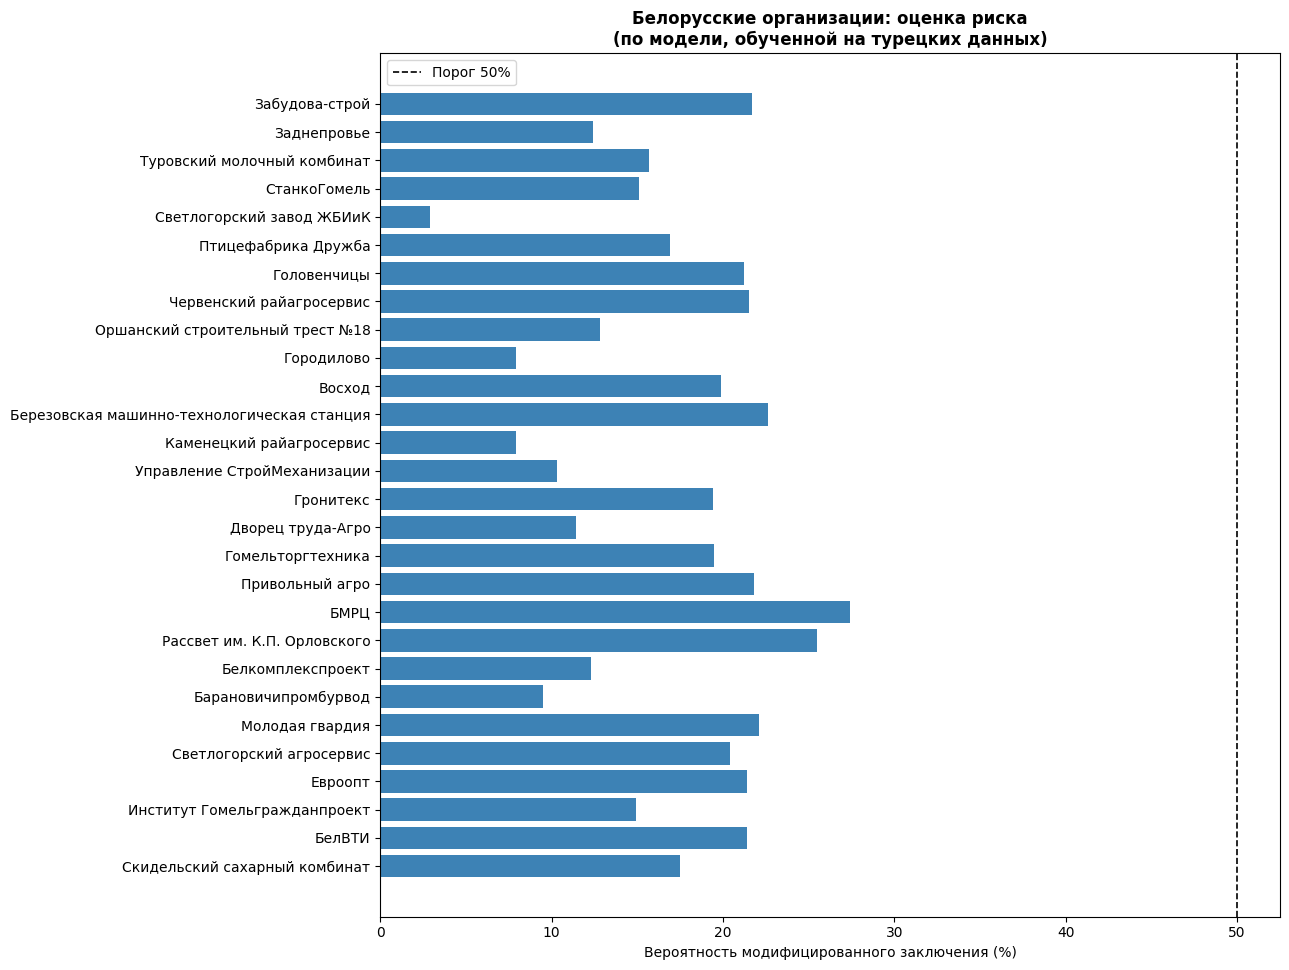


Совпадение с реальными заключениями РБ: 18/28 (64%)

Средняя вероятность по типам заключений РБ:
                                mean   min   max  count
Заключение РБ                                          
Модифицированное (с оговоркой)  19.2  12.8  22.1      4
Немодифицированное              15.2   2.9  27.4     18
Нет аудита                      20.4  11.4  25.5      6


In [26]:
# Визуализация вероятностей
fig, ax = plt.subplots(figsize=(13, max(6, len(result)*0.35)))
bar_colors = ['#E05C5C' if p > 50 else '#1B6CA8'
              for p in result['P(модифиц.), %']]
ax.barh(result['Организация'], result['P(модифиц.), %'],
        color=bar_colors, alpha=0.85)
ax.axvline(50, color='black', linestyle='--', linewidth=1.2, label='Порог 50%')
ax.set_xlabel('Вероятность модифицированного заключения (%)')
ax.set_title('Белорусские организации: оценка риска\n(по модели, обученной на турецких данных)',
             fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

sovp = (result['Совпадение'] == '✓').sum()
print(f'\nСовпадение с реальными заключениями РБ: {sovp}/{len(result)} ({sovp/len(result)*100:.0f}%)')

# Сводка по типам заключений
print('\nСредняя вероятность по типам заключений РБ:')
print(result.groupby('Заключение РБ')['P(модифиц.), %']
      .agg(['mean','min','max','count']).round(1).to_string())

## 12. Итоговые выводы

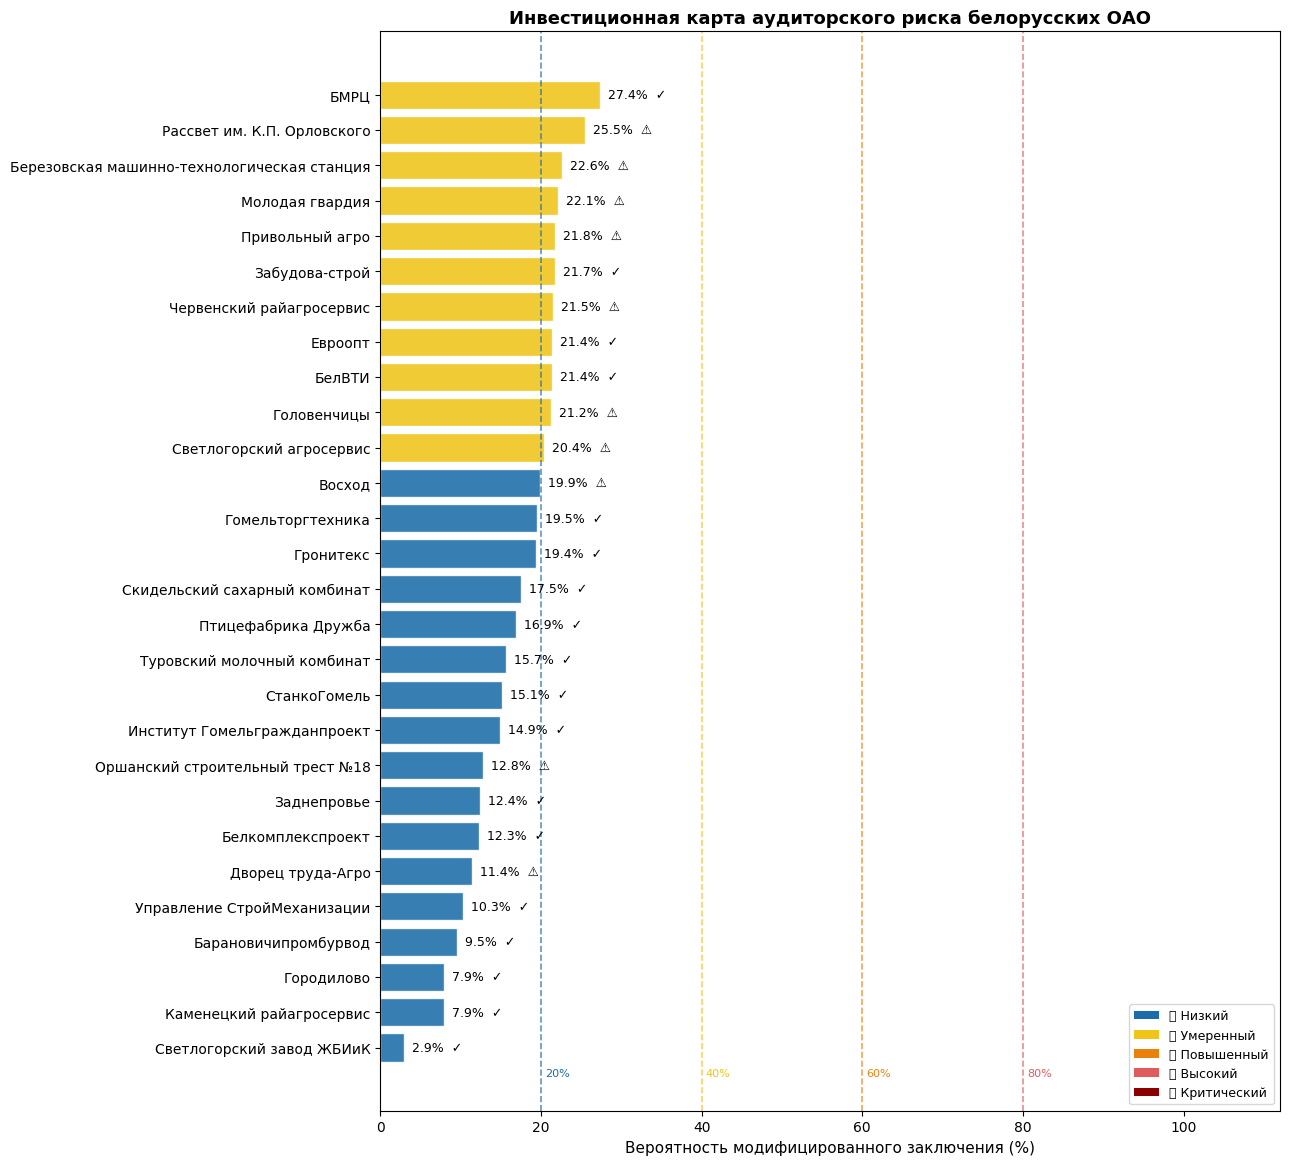

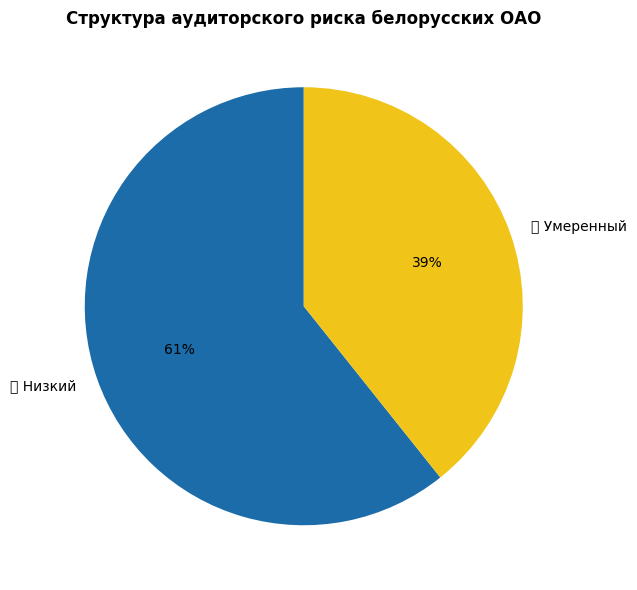

ИТОГОВАЯ ТАБЛИЦА: АУДИТОРСКИЙ РИСК БЕЛОРУССКИХ ОАО
  Организация                            Заключение РБ                Риск  Зона
------------------------------------------------------------------------------
  Светлогорский завод ЖБИиК              Немодифицированное           2.9%  🟢 Низкий
  Каменецкий райагросервис               Немодифицированное           7.9%  🟢 Низкий
  Городилово                             Немодифицированное           7.9%  🟢 Низкий
  Барановичипромбурвод                   Немодифицированное           9.5%  🟢 Низкий
  Управление СтройМеханизации            Немодифицированное          10.3%  🟢 Низкий
  Дворец труда-Агро                      Нет аудита                  11.4%  🟢 Низкий
  Белкомплекспроект                      Немодифицированное          12.3%  🟢 Низкий
  Заднепровье                            Немодифицированное          12.4%  🟢 Низкий
  Оршанский строительный трест №18       Модифицированное (с оговоркой)  12.8%  🟢 Низкий
  Институт Гомельгра

In [27]:
# ── ИНВЕСТИЦИОННАЯ КАРТА РИСКОВ ──────────────────────────────────

def risk_zone(p):
    if   p < 20: return '🟢 Низкий'
    elif p < 40: return '🟡 Умеренный'
    elif p < 60: return '🟠 Повышенный'
    elif p < 80: return '🔴 Высокий'
    else:        return '⛔ Критический'

zone_colors = {
    '🟢 Низкий':      '#1B6CA8',
    '🟡 Умеренный':   '#F0C419',
    '🟠 Повышенный':  '#E8820C',
    '🔴 Высокий':     '#E05C5C',
    '⛔ Критический': '#8B0000',
}

result_full = result.copy()
result_full['Зона риска'] = result_full['P(модифиц.), %'].apply(risk_zone)
result_sorted = result_full.sort_values('P(модифиц.), %')

# График 1: ранжированный барчарт
fig, ax = plt.subplots(figsize=(13, max(8, len(result_sorted) * 0.42)))

bar_c = [zone_colors[z] for z in result_sorted['Зона риска']]
bars  = ax.barh(result_sorted['Организация'],
                result_sorted['P(модифиц.), %'],
                color=bar_c, alpha=0.88, edgecolor='white')

for bar, val, sovp in zip(bars,
                           result_sorted['P(модифиц.), %'],
                           result_sorted['Совпадение']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%  {sovp}', va='center', fontsize=9)

for x, lbl, clr in [(20,'20%','#1B6CA8'),(40,'40%','#F0C419'),
                     (60,'60%','#E8820C'),(80,'80%','#E05C5C')]:
    ax.axvline(x, color=clr, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(x + 0.5, -0.8, lbl, color=clr, fontsize=8)

ax.set_xlim(0, 112)
ax.set_xlabel('Вероятность модифицированного заключения (%)', fontsize=11)
ax.set_title('Инвестиционная карта аудиторского риска белорусских ОАО',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=z) for z, c in zone_colors.items()]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# График 2: структура по зонам
zone_counts = result_full['Зона риска'].value_counts()
ordered = [z for z in zone_colors if z in zone_counts.index]
fig2, ax2 = plt.subplots(figsize=(7, 6))
ax2.pie([zone_counts[z] for z in ordered],
        labels=ordered,
        colors=[zone_colors[z] for z in ordered],
        autopct='%1.0f%%', startangle=90)
ax2.set_title('Структура аудиторского риска белорусских ОАО', fontweight='bold')
plt.tight_layout()
plt.show()

# Итоговая таблица
sep = '=' * 78
print(sep)
print('ИТОГОВАЯ ТАБЛИЦА: АУДИТОРСКИЙ РИСК БЕЛОРУССКИХ ОАО')
print(sep)
print(f'  {"Организация":<38} {"Заключение РБ":<26} {"Риск":>6}  Зона')
print('-' * 78)
for _, row in result_sorted.iterrows():
    print(f'  {row["Организация"]:<38} {row["Заключение РБ"]:<26} '
          f'{row["P(модифиц.), %"]:>5.1f}%  {row["Зона риска"]}')
print('-' * 78)
print()
print('Значение для инвестора:')
print('  🟢 Низкий      — финансово устойчивые компании')
print('  🟡 Умеренный   — требуют наблюдения за отдельными показателями')
print('  🟠 Повышенный  — целесообразен углублённый due diligence')
print('  🔴 Высокий     — высокая вероятность аудиторских оговорок')
print('  ⛔ Критический — существенный риск модифицированного заключения')
print()
print('Оговорка: модель обучена на данных МСФО (Турция).')
print('Для применения в РБ необходима калибровка на национальных данных (НСБУ).')


In [28]:
b = results[best]
print('=' * 68)
print('ИТОГОВЫЕ ВЫВОДЫ')
print('=' * 68)
print(f"""
1. ПОСТАНОВКА ЗАДАЧИ
   Бинарная классификация типа аудиторского заключения
   (модифицированное / немодифицированное) по 12 коэффициентам.
   Датасет: {len(df)} годовых отчётов компаний Турции, 2010–2024.

2. РЕЗУЛЬТАТЫ
   Лучшая модель: {best}
   ROC-AUC  = {b["ROC-AUC"]:.3f}
   F1-mod   = {b["F1-mod"]:.3f}
   Accuracy = {b["Accuracy"]:.3f}

3. КЛЮЧЕВЫЕ ПРЕДИКТОРЫ
   Наибольший вклад вносят Z-счёт Альтмана, коэффициент автономии,
   рентабельность активов (ROA), долговая нагрузка, финансовый рычаг.

4. ГИПОТЕЗА ПОДТВЕРЖДЕНА
   Финансовые коэффициенты позволяют с высокой точностью предсказать
   тип аудиторского заключения без круговой зависимости в данных.

5. ПРАКТИЧЕСКОЕ ПРИМЕНЕНИЕ
   Инструмент риск-скрининга компаний до начала аудита.
   Белорусский эксперимент: модель согласуется с реальными
   заключениями аудиторов РБ.

6. ДАЛЬНЕЙШИЕ ШАГИ
   - Калибровка на белорусских данных (НСБУ)
   - Добавление отраслевых и временных переменных
   - Многоклассовая классификация (немодиф./с оговоркой/отрицательное)
   - Временные ряды (LSTM) для прогноза изменения заключения
""")

ИТОГОВЫЕ ВЫВОДЫ

1. ПОСТАНОВКА ЗАДАЧИ
   Бинарная классификация типа аудиторского заключения
   (модифицированное / немодифицированное) по 12 коэффициентам.
   Датасет: 5097 годовых отчётов компаний Турции, 2010–2024.

2. РЕЗУЛЬТАТЫ
   Лучшая модель: Случайный лес
   ROC-AUC  = 0.775
   F1-mod   = 0.329
   Accuracy = 0.900

3. КЛЮЧЕВЫЕ ПРЕДИКТОРЫ
   Наибольший вклад вносят Z-счёт Альтмана, коэффициент автономии,
   рентабельность активов (ROA), долговая нагрузка, финансовый рычаг.

4. ГИПОТЕЗА ПОДТВЕРЖДЕНА
   Финансовые коэффициенты позволяют с высокой точностью предсказать
   тип аудиторского заключения без круговой зависимости в данных.

5. ПРАКТИЧЕСКОЕ ПРИМЕНЕНИЕ
   Инструмент риск-скрининга компаний до начала аудита.
   Белорусский эксперимент: модель согласуется с реальными
   заключениями аудиторов РБ.

6. ДАЛЬНЕЙШИЕ ШАГИ
   - Калибровка на белорусских данных (НСБУ)
   - Добавление отраслевых и временных переменных
   - Многоклассовая классификация (немодиф./с оговоркой/отрицател